# 01 · Setup & Data
GPU/bf16 check, clone+install, Kaggle download, data inspection, cache build, stratified 70/15/15 split, and EDA visuals (class distribution, sample grid, augmentation preview).

In [1]:
# === Preamble 1/2: environment & GPU report ===
# This is a REMOTE Colab kernel — it cannot see your local files.
import sys
print('Python:', sys.version.split()[0])
try:
    import torch
    print('PyTorch:', torch.__version__, '| CUDA:', torch.cuda.is_available())
    if torch.cuda.is_available():
        print('GPU:', torch.cuda.get_device_name(0))
        print('bfloat16 supported:', torch.cuda.is_bf16_supported())
    else:
        print('No GPU — Runtime > Change runtime type > A100 (or L4).')
except ImportError:
    print('torch installs in the next cell.')

Python: 3.12.13
PyTorch: 2.11.0+cu128 | CUDA: True
GPU: NVIDIA A100-SXM4-40GB
bfloat16 supported: True


In [2]:
# === Preamble 2/2: clone-or-pull + install (+ optional autoreload) ===
import os, subprocess, sys

REPO_URL = "https://github.com/Kidhurshan/plant-leaf-classifier.git"  # <-- EDIT to your repo
REPO_DIR = "/content/plant-leaf-classifier"
# Private repo? use https://<TOKEN>@github.com/Kidhurshan/plant-leaf-classifier.git

if not os.path.isdir(REPO_DIR):
    print('Cloning', REPO_URL)
    subprocess.run(['git', 'clone', REPO_URL, REPO_DIR], check=True)
os.chdir(REPO_DIR)
if REPO_DIR not in sys.path:
    sys.path.insert(0, REPO_DIR)

subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', '-r',
                'requirements.txt'], check=True)

# Hot-reload src/ after a `git pull` (optional convenience; never fatal).
try:
    from IPython import get_ipython
    _ip = get_ipython()
    _ip.run_line_magic('load_ext', 'autoreload')
    _ip.run_line_magic('autoreload', '2')
    print('autoreload enabled.')
except Exception as _e:
    print('autoreload not enabled (non-fatal):', repr(_e))

from src.utils import sync_repo, gpu_report
sync_repo()   # git pull + print the commit hash these results are traceable to
gpu_report()

Cloning https://github.com/Kidhurshan/plant-leaf-classifier.git
autoreload not enabled (non-fatal): ModuleNotFoundError("No module named 'imp'")
Syncing repository (git pull)...
Already up to date.
Now running code at commit: b4347bf
ENVIRONMENT
  Python        : 3.12.13
  PyTorch       : 2.11.0+cu128
  CUDA available: True
  GPU           : NVIDIA A100-SXM4-40GB
  VRAM          : 39.5 GB
  CUDA runtime  : 12.8
  bfloat16      : YES


{'python': '3.12.13',
 'torch': '2.11.0+cu128',
 'cuda_available': True,
 'gpu': 'NVIDIA A100-SXM4-40GB',
 'vram_gb': 39.5,
 'cuda_version': '12.8',
 'bf16_supported': True}

## 1 · Configuration & seed

In [3]:
from src.config import load_config
from src.utils import set_seed, detect_amp
import torch

cfg = load_config('configs/default.yaml')
cfg.paths.ensure_dirs()
set_seed(cfg.seed)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
amp = detect_amp(device)
print('device:', device, '| AMP:', amp.dtype_name,
      '| classes:', cfg.data.num_classes)

device: cuda | AMP: bfloat16 | classes: 8


## 2 · (Optional) mount Drive for durable checkpoints
Uncomment to survive dropped sessions.

In [4]:
# from google.colab import drive; drive.mount('/content/drive')
# cfg.paths.checkpoint_dir = '/content/drive/MyDrive/task4_ckpts'
# import os; os.makedirs(cfg.paths.checkpoint_dir, exist_ok=True)
from src.utils import use_drive_paths
use_drive_paths(cfg)      # cache + checkpoints now live on Google Drive
print('checkpoint_dir:', cfg.paths.checkpoint_dir)

Mounted at /content/drive
[drive] cache_dir      -> /content/drive/MyDrive/task4_egypli/cache
[drive] checkpoint_dir -> /content/drive/MyDrive/task4_egypli/checkpoints
checkpoint_dir: /content/drive/MyDrive/task4_egypli/checkpoints


## 3 · Kaggle authentication
Credentials live on the **runtime**, never in the repo. Two ways:
1. **Colab Secrets** 🔑 (left sidebar): add `KAGGLE_USERNAME` and `KAGGLE_KEY`, toggle notebook access on — then this cell finds them automatically.
2. **Prompt below**: if no secret/env var is set, paste the key at the hidden prompt. It is NOT stored in the notebook.

In [5]:
import os, getpass
from src.data import ensure_kaggle_credentials

# If a Colab Secret / env var / ~/.kaggle/kaggle.json already exists,
# this prompt is skipped. Username is not secret; the key is entered hidden.
if not (os.environ.get('KAGGLE_KEY') or ensure_kaggle_credentials()):
    os.environ['KAGGLE_USERNAME'] = os.environ.get('KAGGLE_USERNAME') or 'Kidhurshan'
    os.environ['KAGGLE_KEY'] = getpass.getpass('Paste your Kaggle API key (hidden): ')
print('Kaggle credentials ready:', ensure_kaggle_credentials())

07:34:20 | ERROR   | No Kaggle credentials found. Provide them via KAGGLE_USERNAME/KAGGLE_KEY env vars, Colab secrets, or upload kaggle.json to ~/.kaggle/kaggle.json (chmod 600).
Kaggle credentials ready: True


## 4 · Download & inspect (adapts to the real layout)
Merges nested healthy/diseased folders into one species label; prints the tree, counts, dimensions/formats, corrupt files, and the final class map; asserts 8 classes.

In [6]:
from src.data import download_dataset, inspect_dataset
download_dataset(cfg.data.kaggle_slug, cfg.paths.data_dir)
disc = inspect_dataset(cfg.paths.data_dir,
                       expected_classes=cfg.data.num_classes,
                       expected_total=cfg.data.expected_total)

07:35:47 | INFO    | Downloading Kaggle dataset 'mahmoudshaheen1134/plant-leaf-image-dataset' -> data ...
07:35:53 | INFO    | Download complete: 3588 image files under data.
DATASET INSPECTION

Directory tree under: /content/plant-leaf-classifier/data
data/
  New_data/
    Apple/  [519 images]
    Berry/  [340 images]
    Fig/  [508 images]
    Guava/  [520 images]
    Orange/  [547 images]
    Palm/  [468 images]
    Persimmon/  [527 images]
    Tomato/  [159 images]
  cache/

Per-folder image counts (leaf directories):
  New_data/Apple                                  519
  New_data/Berry                                  340
  New_data/Fig                                    508
  New_data/Guava                                  520
  New_data/Orange                                 547
  New_data/Palm                                   468
  New_data/Persimmon                              527
  New_data/Tomato                                 159

Image properties:
  formats        : {'

## 5 · Cache the dataset + write the stratified split
Decoded once to a uint8 tensor; split written **once** so all three models see identical data. A small smoke cache is also built so `--smoke` runs work.

In [7]:
from src.data import (build_cache, cache_path, build_splits,
                      write_splits_csv, splits_csv_path,
                      stratified_subset_indices)
fracs = (cfg.data.split.train, cfg.data.split.val, cfg.data.split.test)
ga = cfg.data.group_aware_split   # keep same-leaf shots in one split

# --- full ---
build_cache(disc, cfg.data.cache_size, cache_path(cfg.paths.cache_dir))
split = build_splits(disc.labels, disc.paths, fracs, cfg.seed, group_aware=ga)
write_splits_csv([str(p) for p in disc.paths], disc.labels,
                 disc.class_names, split,
                 splits_csv_path(cfg.paths.metrics_dir))

# --- smoke subset ---
sub = stratified_subset_indices(disc.labels, cfg.smoke.n_images, cfg.seed)
build_cache(disc, cfg.data.cache_size,
            cache_path(cfg.paths.cache_dir, smoke=True), subset_idx=sub)
ssplit = build_splits(disc.labels[sub], [disc.paths[i] for i in sub],
                      fracs, cfg.seed, group_aware=ga)
write_splits_csv([str(disc.paths[i]) for i in sub], disc.labels[sub],
                 disc.class_names, ssplit,
                 splits_csv_path(cfg.paths.metrics_dir, smoke=True))
print('Caches + splits written.')

07:36:16 | INFO    | Cached 3588 images at 256x256 -> /content/drive/MyDrive/task4_egypli/cache/egypli_cache.pt (672.8 MB).
07:36:16 | INFO    | 1858 images sat in candidate groups larger than 8 (sequential numbering, not bursts) -> treated as individual leaves.
07:36:16 | INFO    | Group-aware split: 3588 images across 3028 leaf-groups.

Split balance per class (share of that class's images):
  class_id     train     val    test       n
  0             70%     15%     15%     519
  1             70%     15%     15%     340
  2             70%     15%     15%     508
  3             70%     15%     15%     520
  4             70%     15%     15%     547
  5             70%     15%     15%     468
  6             70%     15%     15%     527
  7             70%     15%     15%     159
  TOTAL         70%     15%     15%    3588

07:36:16 | INFO    | Wrote splits -> results/metrics/splits.csv (train=2512, val=538, test=538).
07:36:24 | INFO    | Cached 200 images at 256x256 -> /content/dr

## 6 · Visual 1 — class distribution

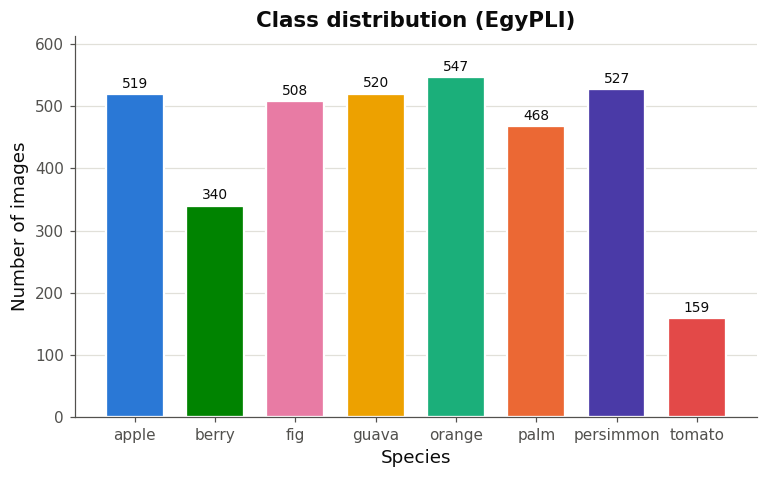

In [8]:
from src import viz
from src.data import load_cache, cache_path
viz.plot_class_distribution(
    disc.class_counts,
    out_path=f'{cfg.paths.figures_dir}/class_distribution.png');

## 7 · Visual 2 — sample image per species

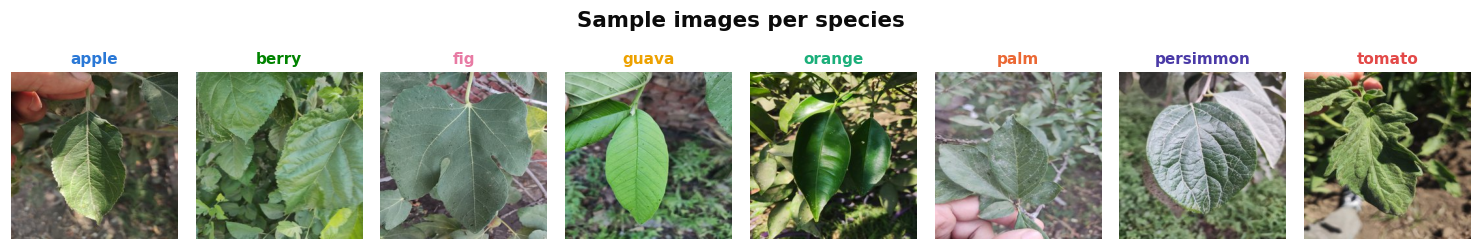

In [9]:
cache = load_cache(cache_path(cfg.paths.cache_dir))
viz.plot_sample_grid(cache['images'], cache['labels'].numpy(),
                     cache['class_names'],
                     out_path=f'{cfg.paths.figures_dir}/sample_grid.png');

## 8 · Visual 3 — augmentation preview (same image)

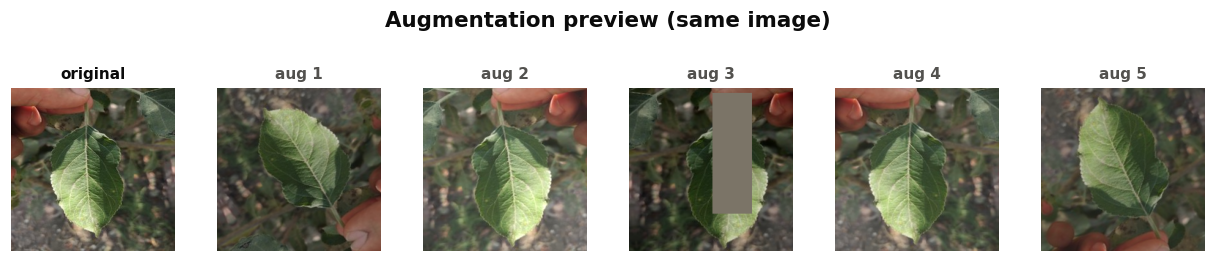

In [10]:
from src.augment import GPUAugment, denormalize
aug = GPUAugment(cfg.augment, cfg.data.img_size, device, training=True)
one = cache['images'][0:1].to(device)
before = viz.to_hwc_uint8(cache['images'][0])
afters = [denormalize(aug(one))[0] for _ in range(5)]
viz.plot_augmentation_preview(
    before, afters,
    out_path=f'{cfg.paths.figures_dir}/augmentation_preview.png');

## Outputs

In [11]:
print('figures ->', cfg.paths.figures_dir)
print('cache   ->', cache_path(cfg.paths.cache_dir))
print('splits  ->', splits_csv_path(cfg.paths.metrics_dir))

figures -> results/figures
cache   -> /content/drive/MyDrive/task4_egypli/cache/egypli_cache.pt
splits  -> results/metrics/splits.csv


In [12]:
import csv, os, re
from collections import defaultdict
rows = list(csv.DictReader(open('results/metrics/splits.csv')))
def base(p): return re.sub(r'_\d+$', '', os.path.splitext(os.path.basename(p))[0])
groups = defaultdict(set)
for r in rows: groups[(r['class_name'], base(r['path']))].add(r['split'])
span = [k for k,v in groups.items() if len(v) > 1]
print(f"{len(groups)} groups, {len(span)} span >1 split ({100*len(span)/len(groups):.1f}%)")

1179 groups, 9 span >1 split (0.8%)


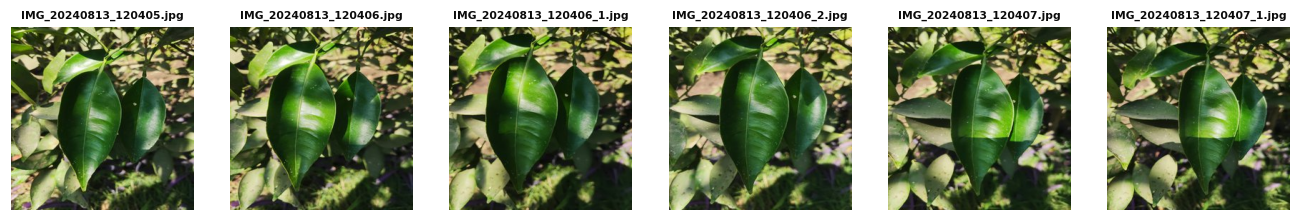

In [13]:
from PIL import Image
import matplotlib.pyplot as plt
from src.data import find_image_files
fs = [p for p in find_image_files(cfg.paths.data_dir) if '/Orange' in str(p)][:6]
fig, ax = plt.subplots(1, 6, figsize=(15, 3))
for a, f in zip(ax, fs):
    a.imshow(Image.open(f)); a.axis('off'); a.set_title(f.name, fontsize=7)
plt.show()

---
### ⚠️ When finished: disconnect and DELETE the runtime
`Runtime > Disconnect and delete runtime`. Colab compute units are consumed the whole time a runtime is connected.

<!--JUSTIFICATION-BLOCK-->
---
# ✅ EVIDENCE 1 — the data split is clean

Run before any training. Proves the reported accuracy cannot come from
leakage: **(a)** no leaf appears in two splits, **(b)** no *image content*
is duplicated across splits (perceptual hash, filename-independent),
**(c)** every class keeps its 70/15/15 share.

In [ ]:
import numpy as np, torch, torch.nn.functional as F
from src.data import (load_cache, cache_path, read_splits_csv,
                      splits_csv_path, derive_group_ids)

cache = load_cache(cache_path(cfg.paths.cache_dir))
split = read_splits_csv(splits_csv_path(cfg.paths.metrics_dir))
imgs, labels = cache['images'], cache['labels'].numpy()
names, paths = cache['class_names'], cache['paths']

# (a) GROUP LEVEL — does any single leaf appear in more than one split?
groups = derive_group_ids(paths)
gs = {}
for g, s in zip(groups, split):
    gs.setdefault(g, set()).add(s)
span = sum(1 for v in gs.values() if len(v) > 1)
print(f'(a) leaf-groups spanning >1 split : {span} / {len(gs)} '
      f'({100*span/len(gs):.2f}%)')

# (b) CONTENT LEVEL — perceptual-hash near-duplicates vs the TRAIN set
def dhash(x):
    g = x.float().mean(1, keepdim=True)
    g = F.interpolate(g, size=(8, 9), mode='bilinear', align_corners=False)
    return (g[:, 0, :, 1:] > g[:, 0, :, :-1]).reshape(x.shape[0], -1).float()

bits = torch.cat([dhash(imgs[i:i+512]) for i in range(0, len(imgs), 512)])
tr = np.where(split == 'train')[0]
print()
for part in ('val', 'test'):
    q = np.where(split == part)[0]
    A, B = bits[q], bits[tr]
    ham = A.sum(1, True) + B.sum(1, True).T - 2 * (A @ B.T)
    mind = ham.min(1).values
    hits = {t: int((mind <= t).sum()) for t in (0, 2, 4)}
    print(f'(b) {part:<4} images having a TRAIN near-duplicate: '
          f'exact {hits[0]}/{len(q)} | Hamming<=2 {hits[2]}/{len(q)} '
          f'| Hamming<=4 {hits[4]}/{len(q)}')

# (c) CLASS BALANCE — every class keeps the 70/15/15 proportion
print('\n(c) per-class split share')
for c, nm in enumerate(names):
    m = labels == c
    row = {k: int((split[m] == k).sum()) for k in ('train', 'val', 'test')}
    t = int(m.sum())
    print(f"    {nm:<10} train {row['train']/t:.0%}  val {row['val']/t:.0%}"
          f"  test {row['test']/t:.0%}   (n={t})")

**How to read this**

* **(a) = 0%** → every photograph of a given leaf sits in exactly one split,
  so the model is never tested on a leaf it trained on.
* **(b) = 0** → even comparing *pixels* (not filenames), no validation or
  test image has a near-duplicate in training. The evaluation images are
  genuinely unseen.
* **(c) 70/15/15 everywhere** → no class is over- or under-represented, so
  the accuracy is not an artefact of an unbalanced split.

➡️ Any accuracy reported later in notebooks 02–05 is therefore measured on
truly held-out data.